# Selecting a Chisel

`CC-BY 2025 Brooksbank, Kassabov, Wilson`

Start by loading `Dleto.jl`.  If this is your first time you may need to install auxilary packages and possibly set up Julia for notebooks.  That is a one-time setup for most users, see instructions here or consider using the fully online Binder demonstration.

---

> **Technical Note** This experiment uses random Gaussian distributions of floating point numbers.  Changing to other random models, e.g. using `rand(...)` in place of `randn(...)` can result in further features.  This is meant as a general tutorial and invidial contexts will have varried outcomes.

In [1]:
# Uncomment and run once if Dleto is not installed
using Pkg
# Option 1: To install from remote repository, use:
# Pkg.add(url="https://github.com/thetensor-space/OpenDleto")
# Option 2: If cloned locally, use:
Pkg.rm("Dleto")
Pkg.develop(path="../../../OpenDleto")

    Updating `~/.julia/environments/v1.10/Project.toml`
  [e7db872f] - Dleto v0.1.0 `../../../CODE/OpenDleto`
    Updating `~/.julia/environments/v1.10/Manifest.toml`
  [e7db872f] - Dleto v0.1.0 `../../../CODE/OpenDleto`
   Resolving package versions...
    Updating `~/.julia/environments/v1.10/Project.toml`
  [e7db872f] + Dleto v0.1.0 `../../../CODE/OpenDleto`
    Updating `~/.julia/environments/v1.10/Manifest.toml`
  [e7db872f] + Dleto v0.1.0 `../../../CODE/OpenDleto`


In [2]:
using Dleto

## Chiseling for Radicals

Our first experiment is the simplest demonstration of chiseling uncovering some form of structure.  This 
We create two tensors, one randomized for control, and a identical in size but with 2 rows, columns, and slices set to all zero.  We then randomize the experiment tensor by applying a change in coordinates.
The goal is to using chiseling to detect and recover the hidden zero rows/columns/slices.

We note that this experiment is extremely basic and there are faster algorithms to recover this structure known under the names of **detecting radicals** or **Tucker decompositions**.  `Delto.jl` makes use of those faster methods for large scale experiments, but this experiment simply uses generic Delto methods to explore what is possible.

In [3]:
ds = (5,5,5); rs = (2,2,2);
ctr_t = randn(Float64, ds);
exp_t = zeros(Float64, ds);          
exp_t[1:(ds[1]-rs[1]), 1:(ds[2]-rs[2]), 1:(ds[3]-rs[3])] .= randn(Float64,(ds[1]-rs[1]),(ds[2]-rs[2]),(ds[3]-rs[3]));

sidebyside(ctr_t, exp_t; left_title="Control", right_title="Experiment")

Control 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 0.229077 -0.925014 -1.55212 -0.537442 1.4821
 0.877757 -0.236405 0.204716 0.221205 1.06439
 0.663522 0.0616199 -0.430251 0.189182 -1.20517
 0.793155 1.3401 -0.696336 -1.57299 -0.309488
 0.290579 0.863354 0.348789 2.44627 -1.29591

[:, :, 2] =
 0.0459733 1.07994 0.225286 0.169374 0.271751
 0.451955 -0.677875 1.41637 -0.684015 0.0628903
 -0.1086 -1.90681 -0.592196 -0.237801 0.455541
 0.379897 0.758494 0.282418 0.0230594 -2.02974
 0.888736 -0.979153 -2.17105 2.92289 0.699286

[:, :, 3] =
 0.492834 -1.58745 -1.00491 -0.2463 -1.80384
 1.0148 -0.713715 -0.250326 -2.64498 -0.277763
 -1.07578 -1.07082 1.07591 0.337338 1.20468
 0.483239 0.300926 0.000961051 -0.0684688 -0.344218
 -0.802905 -0.0944667 0.644379 0.969877 0.0952147

[:, :, 4] =
 -0.552126 0.44779 -1.15677 -2.21771 -0.741837
 0.888854 1.10299 1.1299 -0.874838 1.12809
 1.80513 -0.435283 0.954343 -0.39927 -0.178835
 0.690055 -0.34001 -1.83084 0.231717 1.55555
 1.18991 0.482706 -0.0518222 1.74401 -1.06378

[:, :, 5] =
 0.112702 0.573118 0.768593 -0.194117 1.06356
 -1.51245 -0.49124 0.495267 -1.21177 0.942276
 -1.23098 0.0475502 1.04892 -0.484528 -1.26561
 -0.312729 0.650683 -1.39837 0.973197 1.25659
 -0.771402 -0.430132 -0.609656 -1.73625 -1.02082 
 
 
 Experiment 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 0.0575237 -1.41969 0.557029 0.0 0.0
 -0.43554 -1.4431 0.208481 0.0 0.0
 -1.16424 1.87242 -0.675215 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

[:, :, 2] =
 0.825808 1.44576 0.242352 0.0 0.0
 -1.2875 -0.0412332 2.56305 0.0 0.0
 1.37116 0.778775 0.2803 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

[:, :, 3] =
 -1.01561 -0.769425 0.764155 0.0 0.0
 1.9821 0.552859 0.251949 0.0 0.0
 -0.495684 0.725617 0.103762 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

[:, :, 4] =
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

[:, :, 5] =
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

The control tensor very likely has few to no all zero axes whereas the experiment evidently does.  The role of chiseling is to recover such anamolies without knowing ahead of time.  So we now randomize the experiment so as to obscure this data.  Note that the randomization applies random bases change so the original coordinates.  

It should now be much less obvious that the control and experminet are any different.

In [4]:
res = randomize(exp_t);
exp_t = res.tensor;  # res.matrices stores the randomization matrices

sidebyside(ctr_t, exp_t; left_title="Control", right_title="Experiment")

Control 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 0.229077 -0.925014 -1.55212 -0.537442 1.4821
 0.877757 -0.236405 0.204716 0.221205 1.06439
 0.663522 0.0616199 -0.430251 0.189182 -1.20517
 0.793155 1.3401 -0.696336 -1.57299 -0.309488
 0.290579 0.863354 0.348789 2.44627 -1.29591

[:, :, 2] =
 0.0459733 1.07994 0.225286 0.169374 0.271751
 0.451955 -0.677875 1.41637 -0.684015 0.0628903
 -0.1086 -1.90681 -0.592196 -0.237801 0.455541
 0.379897 0.758494 0.282418 0.0230594 -2.02974
 0.888736 -0.979153 -2.17105 2.92289 0.699286

[:, :, 3] =
 0.492834 -1.58745 -1.00491 -0.2463 -1.80384
 1.0148 -0.713715 -0.250326 -2.64498 -0.277763
 -1.07578 -1.07082 1.07591 0.337338 1.20468
 0.483239 0.300926 0.000961051 -0.0684688 -0.344218
 -0.802905 -0.0944667 0.644379 0.969877 0.0952147

[:, :, 4] =
 -0.552126 0.44779 -1.15677 -2.21771 -0.741837
 0.888854 1.10299 1.1299 -0.874838 1.12809
 1.80513 -0.435283 0.954343 -0.39927 -0.178835
 0.690055 -0.34001 -1.83084 0.231717 1.55555
 1.18991 0.482706 -0.0518222 1.74401 -1.06378

[:, :, 5] =
 0.112702 0.573118 0.768593 -0.194117 1.06356
 -1.51245 -0.49124 0.495267 -1.21177 0.942276
 -1.23098 0.0475502 1.04892 -0.484528 -1.26561
 -0.312729 0.650683 -1.39837 0.973197 1.25659
 -0.771402 -0.430132 -0.609656 -1.73625 -1.02082 
 
 
 Experiment 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 5.46029 -4.86889 3.59531 6.22207 -3.52691
 3.81588 -1.77408 2.22112 5.75898 -2.87249
 1.42619 0.442247 6.02514 7.22569 10.4746
 1.82204 -1.63698 -1.30083 0.155508 -6.66169
 1.89531 0.915289 3.84681 6.75591 4.84442

[:, :, 2] =
 -0.821163 0.144752 -2.91558 -3.33738 -4.76053
 -0.405499 2.50039 -2.77832 -0.233791 -4.94098
 -3.87387 -6.2247 2.37215 -10.3638 11.9221
 1.50524 4.10847 -2.78346 4.30074 -8.47479
 -2.19627 -1.10603 0.0270634 -4.45152 4.2137

[:, :, 3] =
 -1.92375 -0.845107 -1.60827 -5.02065 0.129919
 -1.09479 -4.79215 1.94734 -4.99601 5.73854
 -3.94929 6.61441 -7.89966 -5.44295 -8.6297
 1.07774 -5.47467 4.41153 -0.473179 6.78008
 -2.3768 -0.616857 -1.73314 -5.58075 0.777899

[:, :, 4] =
 -2.16267 3.82286 -1.92588 -0.947576 0.565496
 -1.65954 5.853 -3.90844 0.34568 -4.4811
 1.04275 -7.71814 3.40047 -3.54827 4.31315
 -1.539 6.85092 -3.68657 1.70035 -4.08947
 0.0146299 -0.440718 -1.01659 -1.19543 -2.32043

[:, :, 5] =
 2.72367 -3.46186 0.513407 1.09063 -4.71268
 2.05939 -1.34185 0.682326 2.32845 -2.73715
 -2.10609 -0.882774 2.96396 -1.84811 10.5082
 2.29144 -0.646994 -0.986405 2.10705 -6.75309
 -0.499741 -0.110255 2.11067 0.73507 5.59352

Now let us use the universal chisel to begin exploring. This is the default choice, so calling `chisel` will get us going.

Jargon alert: “Dleto” means “chisel,” and “spall” is the material that comes off a block when chiseling. In tensors, chiseling produces a list of scalars and a list of matrices; together we call this the spall.

In [5]:
exp_spall = chisel(exp_t);

Chiseling tensor of size (5, 5, 5) with constraint matrix of size (125, 75)
Computing SVD via LinearAlgebra...(125, 75)
SVD S (75,) U (75, 75)
Computed 75 singular values, returning 10 smallest.


You see the default setting used only 10 of the available 75 values.  The value $75=3\cdot 5^2$ coincides with being a 3-valent tensor with dimensions `(5,5,5)` so it will take three $5\times 5$-operators to manipulate for a total of 75 parameters.  However there are also $125=5^3$ constraint equations so we should expect few solutions.  Thus as a practical improvement, `Dleto.jl` estimates only 10 solutions will be necessary and accelorate the calculations knowing this heuristic value.

To explain the process in full, let us override this heuristic cut-off and take all the available values.  Note, if we give `chisel` a number greater than the available values or one that is negative, then all values are computed. 

In [6]:
exp_spall = chisel(exp_t, 175);
ctr_spall = chisel(ctr_t, 175);


Chiseling tensor of size (5, 5, 5) with constraint matrix of size (125, 75)
Computing SVD via LinearAlgebra...(125, 75)
SVD S (75,) U (75, 75)
Computed 75 singular values, returning 75 smallest.
Chiseling tensor of size (5, 5, 5) with constraint matrix of size (125, 75)
Computing SVD via LinearAlgebra...(125, 75)
SVD S (75,) U (75, 75)
Computed 75 singular values, returning 75 smallest.


Spalls have two types of data, a list of values `xxx_t.values` and a list of vectors `xxx_t.vectors`.  We can example the values by comparing the control to the experiment.  Often plots can communicate the differences.  

## Features
 * In the control, there are 2 values that are very close to zero, followed by a small jump and then gradually growing values.
 * In the experiment with `ds=(5,5,5)` and `rs=(2,2,2)` there are more than 30 nearly 0 values.
 * Both the control and the experiment accelorate near the end.

To experiment further, adjust the dimensions in Cell 2 from `(5,5,5)` to `(3,5,10)`, or increase the random contribution of to `exp_t` from `rand(3,3,3)` to `rand(5,3,3)`.  Rerun each cell in this section and watch for changes.  

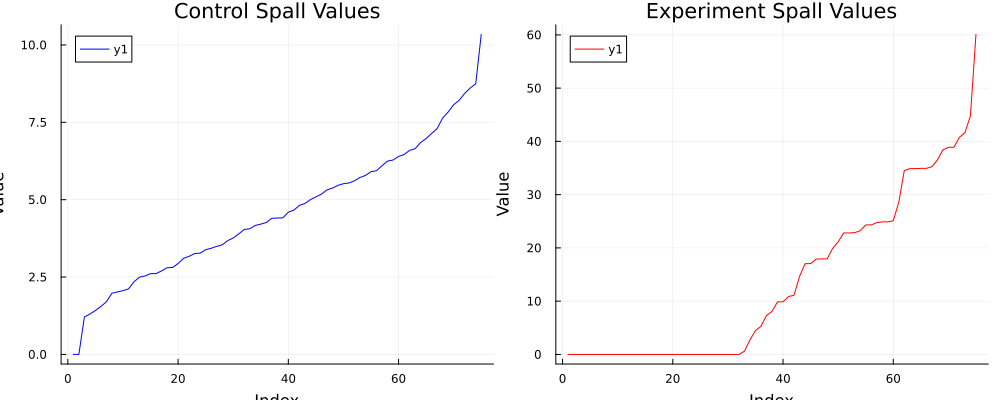

In [7]:
# using Pkg; Pkg.add("Plots"). ## uncommnet if Plots not installed, only needed once
using Plots 

p1 = plot(ctr_spall.values,  xlabel="Index", ylabel="Value", title="Control Spall Values", color=:blue)
p2 = plot(exp_spall.values,  xlabel="Index", ylabel="Value", title="Experiment Spall Values", color=:red)
plot(p1, p2, layout=(1,2), size=(1000, 400))

The behavior demonstrated is a response to the number of 0's we included as rows, columns, and slices in the experiment.  It may become more noticeable to plot the derviatives, using `diff(xxx_t.values)`.  

Unfortunately, the steep changes in behavior near the final values can overwhellem the comparisons we are after near the small values, which is what we care to track.  Those carry little useable information as we can see they occur at the same range.  It is for this reason that we typically do not include the larger values.  By replotting the data with smaller range we can better see the differences between control and experiment.

**We are interested in the index location of the first spike in the differences.**

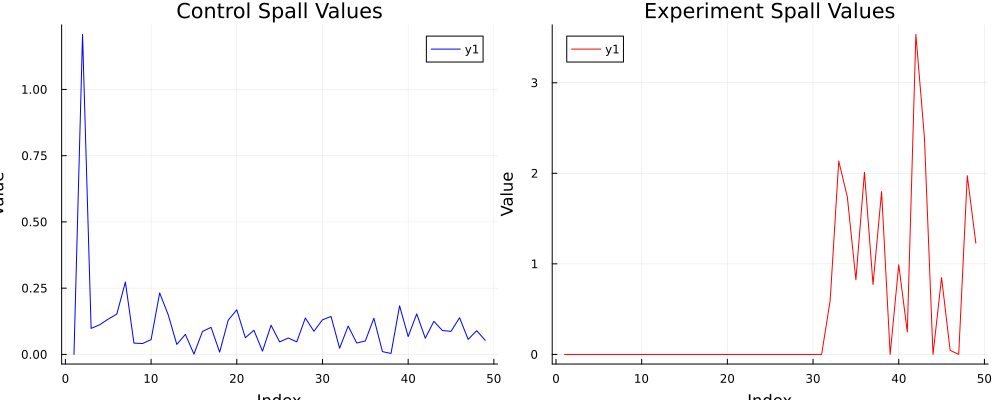

In [8]:
p1 = plot(diff(ctr_spall.values[1:50]),  xlabel="Index", ylabel="Value", title="Control Spall Values", color=:blue)
p2 = plot(diff(exp_spall.values[1:50]),  xlabel="Index", ylabel="Value", title="Experiment Spall Values", color=:red)
plot(p1, p2, layout=(1,2), size=(1000, 400))

You may notice the number of 0's in the experimental plot increase with the number of all zero rows, columns, and slices. You may even be able to estimate a formula on the order of the following.
```math
2 + d_1\cdot r_1 + d_2 \cdot r_2 + d_3\cdot r_3
```
> While not important to chisel selection, the orgin of this formula can be seen as the number of matrices mapping $\mathbb{R}^{d_i}\to \mathbb{R}^{r_i}$ for each axis $i\in \{1,2,3\}$ plus the initial 2 dimensions that are present for all tensors of valence 2.  Note that these numbers are also specific to the universal chisel which we get by default when using `chisel(xxx_t)`.

## Recovering blocks from the chiseling spall


In [10]:
sculpted_ctr = sculpt(ctr_t, ctr_spall, collect(3:3));
sculpted_exp = sculpt(exp_t, exp_spall, collect(3:3));
sidebyside(round.(100*sculpted_ctr.tensor), round.(100*sculpted_exp.tensor); 
left_title="Control Sculpted Vec", right_title="Experiment Sculpted Vec")

Control Sculpted Vec 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 8.0 16.0 4.0 14.0 -19.0
 -67.0 4.0 -41.0 24.0 33.0
 -1.0 -8.0 -0.0 -18.0 -33.0
 -41.0 -2.0 -63.0 -5.0 -49.0
 -65.0 -2.0 -12.0 50.0 2.0

[:, :, 2] =
 0.0 21.0 3.0 27.0 -24.0
 -55.0 4.0 -8.0 12.0 9.0
 -6.0 -11.0 -11.0 -23.0 -13.0
 -58.0 7.0 -82.0 1.0 -11.0
 -60.0 -26.0 -12.0 17.0 12.0

[:, :, 3] =
 -57.0 4.0 -3.0 17.0 -3.0
 -29.0 4.0 40.0 2.0 15.0
 26.0 6.0 16.0 1.0 -14.0
 69.0 25.0 -37.0 -4.0 -15.0
 -31.0 -13.0 25.0 -3.0 -5.0

[:, :, 4] =
 16.0 4.0 9.0 17.0 -31.0
 -3.0 9.0 -10.0 3.0 16.0
 -20.0 -0.0 -22.0 -3.0 16.0
 -16.0 14.0 -28.0 -0.0 12.0
 -17.0 -8.0 -8.0 1.0 16.0

[:, :, 5] =
 12.0 -53.0 -172.0 -8.0 21.0
 -48.0 -9.0 -30.0 13.0 -14.0
 -8.0 -17.0 -28.0 -12.0 -6.0
 -7.0 -7.0 -54.0 -5.0 1.0
 5.0 3.0 38.0 -12.0 -19.0 
 
 
 Experiment Sculpted Vec 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 -0.0 0.0 0.0 -0.0 0.0
 -0.0 0.0 -0.0 -0.0 -0.0
 -0.0 0.0 0.0 -0.0 -0.0
 0.0 0.0 -0.0 0.0 0.0
 -0.0 -0.0 0.0 -0.0 -0.0

[:, :, 2] =
 -0.0 0.0 -0.0 0.0 0.0
 -0.0 0.0 -0.0 -0.0 -0.0
 0.0 -0.0 0.0 0.0 0.0
 -0.0 -0.0 0.0 -0.0 -0.0
 0.0 0.0 -0.0 0.0 0.0

[:, :, 3] =
 0.0 0.0 -0.0 -0.0 0.0
 0.0 -0.0 -0.0 -0.0 0.0
 0.0 -41.0 7.0 205.0 -0.0
 0.0 -62.0 152.0 -90.0 -0.0
 -0.0 62.0 -152.0 90.0 0.0

[:, :, 4] =
 0.0 -0.0 -0.0 0.0 -0.0
 0.0 -0.0 -0.0 -0.0 -0.0
 -0.0 9.0 161.0 -183.0 -0.0
 0.0 -26.0 -34.0 5.0 -0.0
 -0.0 26.0 34.0 -5.0 0.0

[:, :, 5] =
 -0.0 0.0 0.0 -0.0 0.0
 -0.0 0.0 0.0 0.0 0.0
 0.0 -9.0 -161.0 183.0 0.0
 -0.0 26.0 34.0 -5.0 0.0
 0.0 -26.0 -34.0 5.0 -0.0